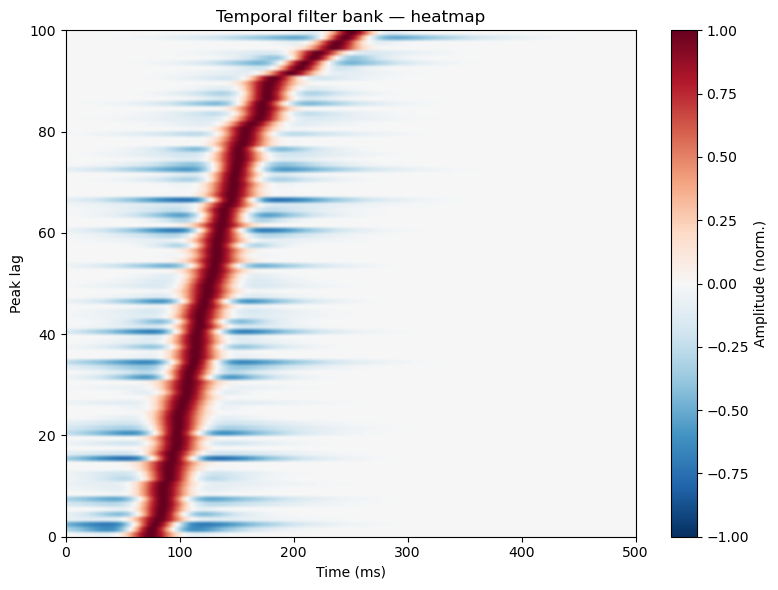

In [28]:

import numpy as np
import matplotlib.pyplot as plt

# ── parameters ──────────────────────────────────────────────────────────────
N_FILTERS   = 100
T           = np.arange(0, 1000)          # ms, 0–1000
LAG_MIN, LAG_MAX = 80, 300              # ms

# skew controls the Gamma shape: higher = more uniform, lower = more skewed toward short lags
SKEW        = 2.0  
RNG_SEED    = 100

rng = np.random.default_rng(RNG_SEED)

# ── sample peak lags from a Gamma distribution, clipped to [LAG_MIN, LAG_MAX] ─
raw = rng.gamma(shape=SKEW, scale=10.0, size=N_FILTERS * 10) + np.random.uniform(-10, 10, N_FILTERS * 10)  # add some jitter
raw = raw / raw.max()                    # normalise to [0, 1]
lags = (raw * (LAG_MAX - LAG_MIN) + LAG_MIN).astype(int)
lags = lags[lags < LAG_MAX][:N_FILTERS]
lags = np.sort(lags)

# ── build filters (difference of Gaussians) ──────────────────────────────────
sigma_narrow = 15.0                      # ms, fixed

def dog(t, mu, sigma1, sigma2, amp2):
    g1 = np.exp(-0.5 * ((t - mu) / sigma1) ** 2)
    g2 = amp2 * np.exp(-0.5 * ((t - mu) / sigma2) ** 2)
    f  = g1 - g2
    f  = f / np.abs(f).max() 
    return f

sigma2_vals = rng.uniform(1, 5.0, N_FILTERS) * sigma_narrow
amp2_vals   = rng.uniform(0.1, 0.5, N_FILTERS)

filters = np.array([
    dog(T, lags[i], sigma_narrow, sigma2_vals[i], amp2_vals[i])
    for i in range(N_FILTERS)
])


# ── heatmap plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    filters,
    aspect='auto',
    origin='lower',
    extent=[T[0], T[-1], 0, N_FILTERS],
    cmap='RdBu_r',
    vmin=-1, vmax=1,
)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Peak lag")
ax.set_title("Temporal filter bank — heatmap")
ax.set_xlim(0, 500)
plt.colorbar(im, ax=ax, label="Amplitude (norm.)")
plt.tight_layout()

loc = "/Users/benjaminscholl/Dropbox/projects/VisBehavDev/rawfigures/"
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(f'{loc}/CoarseToFine.svg', 
            format='svg', 
            bbox_inches='tight')
plt.show()
